# Credit Card Fraud Detection

- Anonymized credit card transactions labeled as fraudulent or genuine

## 데이터 로드 및 탐색

In [12]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Gaten\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(file_path)

print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [14]:
counts = df['Class'].value_counts()
print(counts)

Class
0    284315
1       492
Name: count, dtype: int64


C:\Users\Gaten\AppData\Local\Temp\ipykernel_16740\4261661756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


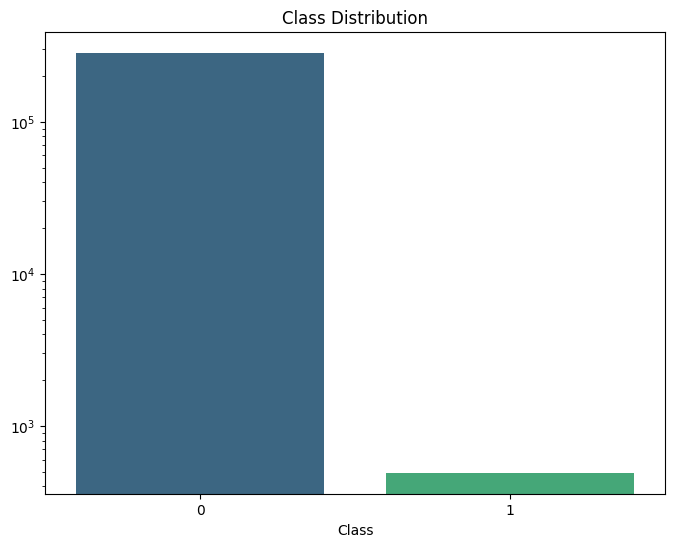

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Class Distribution')
plt.yscale('log')
plt.show()

## 데이터 전처리

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['std_amount'] = scaler.fit_transform(df[['Amount']])
df['std_time'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)

print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  std_amount  std_time  
0 -0.

## 학습용 데이터 분리

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("학습 데이터 크기 ", X_train.shape)
print("테스트 데이터 크기 ", X_test.shape)

학습 데이터 크기  (227845, 30)
테스트 데이터 크기  (56962, 30)


- 28만 건의 금융 결제 데이터 중 0.17%에 불과한 사기 거래 탐지를 위해, StandardScaler를 통한 피처 엔지니어링 및 Stratified Split 전략을 사용하여 데이터 편향 문제를 먼저 해결함

## 학습

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_ts = torch.FloatTensor(X_train.values)
y_train_ts = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_ts = torch.FloatTensor(X_test.values)
y_test_ts = torch.FloatTensor(y_test.values).view(-1, 1)

train_ds = TensorDataset(X_train_ts, y_train_ts)
test_ds = TensorDataset(X_test_ts, y_test_ts)

train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)

In [19]:
class FraudDetectionModel(nn.Module):
    def __init__(self, input_dim):
        super(FraudDetectionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

model = FraudDetectionModel(X_train.shape[1])

In [20]:
fraud_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
pos_weight = torch.tensor([fraud_weight])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 

criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
epochs = 20
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

print("학습 완료!")

Epoch [5/20], Loss: 0.0042
Epoch [10/20], Loss: 0.0030
Epoch [15/20], Loss: 0.0027
Epoch [20/20], Loss: 0.0025
학습 완료!


## 예측

In [22]:
model.eval()
y_pred_list = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model(batch_x)
        y_pred = (outputs > 0.5).float()
        y_pred_list.append(y_pred)

y_pred_all = torch.cat(y_pred_list, dim=0).numpy()

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(classification_report(y_test, y_pred_all, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



- 데이터 내 사기 거래 비중이 0.17%인 극심한 클래스 불균형 환경
- output이 0.5보다 큰 경우를 분석함
- PyTorch 기반 DNN 모델을 통해 Fraud Recall 0.82 달성

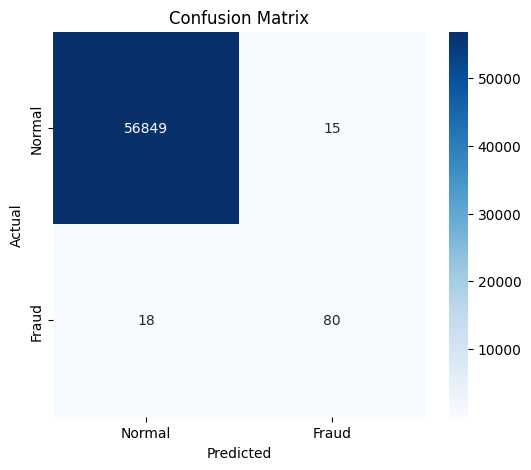

In [24]:
cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()